# Couple Left side and Right side of fin

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import image_grid
from wildlife_tools.data import FeatureDataset

In [11]:
features = FeatureDataset.from_file("/media/filming/2025-白海豚/20240824_JM_01/FILTERED_deepfeatures_with_label")
root_dir = "/media/filming/2025-白海豚/20240824_JM_01/"

In [12]:
features.metadata

,img_id,path,x_min,x_max,y_min,y_max,orig_img,crop_conf,orig_img_h,orig_img_w,clearness,select,identity,TmpID,FinID
0,0,FIN/1214_20240824JM01ZRA11214_FIN00.JPG,3403,4110,2776,3200,1214_20240824JM01ZRA11214.JPG,0.669546,5760,8640,0.316150,True,0,1,1
1,1,FIN/1215_20240824JM01ZRA11215_FIN00.JPG,3597,4297,2754,3204,1215_20240824JM01ZRA11215.JPG,0.804073,5760,8640,0.671580,True,1,1,1
2,2,FIN/1216_20240824JM01ZRA11216_FIN00.JPG,3695,4441,2774,3226,1216_20240824JM01ZRA11216.JPG,0.791573,5760,8640,0.709832,True,2,1,1
3,3,FIN/1217_20240824JM01ZRA11217_FIN00.JPG,3711,4453,2796,3238,1217_20240824JM01ZRA11217.JPG,0.824041,5760,8640,0.633289,True,3,1,1
4,4,FIN/1218_20240824JM01ZRA11218_FIN00.JPG,3731,4435,2806,3239,1218_20240824JM01ZRA11218.JPG,0.831123,5760,8640,0.262074,True,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1721,2618,FIN/0057_20240824JM01ZRA10057_FIN00.JPG,1827,2240,1296,1530,0057_20240824JM01ZRA10057.JPG,0.873636,2880,4320,0.997790,True,2618,96,96
1722,2623,FIN/0044_20240824JM01ZRA10044_FIN00.JPG,2192,2423,1561,1688,0044_20240824JM01ZRA10044.JPG,0.813805,2880,4320,0.110677,True,2623,97,97
1723,2624,FIN/0045_20240824JM01ZRA10045_FIN00.JPG,2170,2434,1533,1677,0045_20240824JM01ZRA10045.JPG,0.835904,2880,4320,0.470295,True,2624,97,97
1724,2625,FIN/0046_20240824JM01ZRA10046_FIN00.JPG,2137,2427,1526,1678,0046_20240824JM01ZRA10046.JPG,0.833445,2880,4320,0.618249,True,2625,97,97


In [13]:
features.metadata = features.metadata.drop(columns='img_id')

In [121]:
features.metadata = features.metadata.drop(columns='TmpID')

In [14]:
features.metadata

,path,x_min,x_max,y_min,y_max,orig_img,crop_conf,orig_img_h,orig_img_w,clearness,select,identity,TmpID,FinID
0,FIN/1214_20240824JM01ZRA11214_FIN00.JPG,3403,4110,2776,3200,1214_20240824JM01ZRA11214.JPG,0.669546,5760,8640,0.316150,True,0,1,1
1,FIN/1215_20240824JM01ZRA11215_FIN00.JPG,3597,4297,2754,3204,1215_20240824JM01ZRA11215.JPG,0.804073,5760,8640,0.671580,True,1,1,1
2,FIN/1216_20240824JM01ZRA11216_FIN00.JPG,3695,4441,2774,3226,1216_20240824JM01ZRA11216.JPG,0.791573,5760,8640,0.709832,True,2,1,1
3,FIN/1217_20240824JM01ZRA11217_FIN00.JPG,3711,4453,2796,3238,1217_20240824JM01ZRA11217.JPG,0.824041,5760,8640,0.633289,True,3,1,1
4,FIN/1218_20240824JM01ZRA11218_FIN00.JPG,3731,4435,2806,3239,1218_20240824JM01ZRA11218.JPG,0.831123,5760,8640,0.262074,True,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1721,FIN/0057_20240824JM01ZRA10057_FIN00.JPG,1827,2240,1296,1530,0057_20240824JM01ZRA10057.JPG,0.873636,2880,4320,0.997790,True,2618,96,96
1722,FIN/0044_20240824JM01ZRA10044_FIN00.JPG,2192,2423,1561,1688,0044_20240824JM01ZRA10044.JPG,0.813805,2880,4320,0.110677,True,2623,97,97
1723,FIN/0045_20240824JM01ZRA10045_FIN00.JPG,2170,2434,1533,1677,0045_20240824JM01ZRA10045.JPG,0.835904,2880,4320,0.470295,True,2624,97,97
1724,FIN/0046_20240824JM01ZRA10046_FIN00.JPG,2137,2427,1526,1678,0046_20240824JM01ZRA10046.JPG,0.833445,2880,4320,0.618249,True,2625,97,97


In [26]:
import os
import glob

In [102]:
# find the dophin id from folder structure
dolphin_list = glob.glob(os.path.join(root_dir + "/FIN", 'TmpID*'))
dolphin_list.sort()
for dolphin in dolphin_list:
    dolphin_id = int(os.path.basename(dolphin)[5:])
    fin_list  = glob.glob(os.path.join(dolphin, 'FinID*'))
    for fin in fin_list:
        fin_id = int(os.path.basename(fin)[5:])
        features.metadata.loc[ features.metadata['FinID']==fin_id, "DolphinID"] = dolphin_id
features.metadata.to_csv(root_dir + "/FILTERED_metainfo_with_FinID_with_dolphinID.csv")
features.save(root_dir + "FILTERED_deepfeatures_with_label_with_dolphinID")

In [41]:
fin_img_list = glob.glob(os.path.join( fin_list[0], '*.JPG'))
fin_img_name = os.path.basename(fin_img_list[0])

In [123]:
metadata = features.metadata

In [112]:
import os
import shutil
from pathlib import Path

In [113]:
def creat_empty_folder(folder):
    folder_path = Path(folder)
    if folder_path.exists():
        shutil.rmtree(folder_path)
        print(f"Deleted: {folder_path}")
    os.mkdir(folder)


In [119]:
# move original image to subfolder
max_tmpid = features.metadata["DolphinID"].max()

for i in range(1, max_tmpid+1):
    paths = features.metadata.query("DolphinID==%d"%i)['orig_img']
    dest_dir = root_dir + "/TmpID%03d/"%i
    creat_empty_folder(dest_dir)
    for dolphin in paths:
        src = root_dir + "/" + dolphin
        dest = dest_dir + dolphin
        if not os.path.exists(dest):
            os.symlink(src, dest)

Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID001
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID002
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID003
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID004
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID005
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID006
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID007
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID008
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID009
Deleted: /media/filming/2025-白海豚/20240824_JM_01/TmpID010


In [296]:
    paths = features.metadata.query("DolphinID==1")['orig_img']
    dest_dir = root_dir + "/DphID%03d/"%1
    creat_empty_folder(dest_dir)
    for dolphin in paths:
        src = root_dir + "/" + dolphin
        dest = dest_dir + dolphin
        if not os.path.exists(dest):
            os.symlink(src, dest)

Deleted: /media/filming/2025-白海豚/20240824_JM_01/DphID001


In [295]:
paths

0       1214_20240824JM01ZRA11214.JPG
1       1215_20240824JM01ZRA11215.JPG
2       1216_20240824JM01ZRA11216.JPG
3       1217_20240824JM01ZRA11217.JPG
4       1218_20240824JM01ZRA11218.JPG
5       1219_20240824JM01ZRA11219.JPG
6       1220_20240824JM01ZRA11220.JPG
7       1222_20240824JM01ZRA11222.JPG
8       1223_20240824JM01ZRA11223.JPG
9       1224_20240824JM01ZRA11224.JPG
10      1225_20240824JM01ZRA11225.JPG
143     1374_20240824JM01ZRA11374.JPG
144     1375_20240824JM01ZRA11375.JPG
145     1376_20240824JM01ZRA11376.JPG
146     1377_20240824JM01ZRA11377.JPG
147     1378_20240824JM01ZRA11378.JPG
149     1379_20240824JM01ZRA11379.JPG
247     1518_20240824JM01ZRA11518.JPG
249     1519_20240824JM01ZRA11519.JPG
250     1520_20240824JM01ZRA11520.JPG
252     1521_20240824JM01ZRA11521.JPG
254     1522_20240824JM01ZRA11522.JPG
255     1523_20240824JM01ZRA11523.JPG
1446    0969_20240824JM01ZRA10969.JPG
1447    0970_20240824JM01ZRA10970.JPG
1448    0971_20240824JM01ZRA10971.JPG
1449    0972

In [125]:
features.metadata

,path,x_min,x_max,y_min,y_max,orig_img,crop_conf,orig_img_h,orig_img_w,clearness,select,identity,FinID,DolphinID
0,FIN/1214_20240824JM01ZRA11214_FIN00.JPG,3403,4110,2776,3200,1214_20240824JM01ZRA11214.JPG,0.669546,5760,8640,0.316150,True,0,1,1
1,FIN/1215_20240824JM01ZRA11215_FIN00.JPG,3597,4297,2754,3204,1215_20240824JM01ZRA11215.JPG,0.804073,5760,8640,0.671580,True,1,1,1
2,FIN/1216_20240824JM01ZRA11216_FIN00.JPG,3695,4441,2774,3226,1216_20240824JM01ZRA11216.JPG,0.791573,5760,8640,0.709832,True,2,1,1
3,FIN/1217_20240824JM01ZRA11217_FIN00.JPG,3711,4453,2796,3238,1217_20240824JM01ZRA11217.JPG,0.824041,5760,8640,0.633289,True,3,1,1
4,FIN/1218_20240824JM01ZRA11218_FIN00.JPG,3731,4435,2806,3239,1218_20240824JM01ZRA11218.JPG,0.831123,5760,8640,0.262074,True,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1721,FIN/0057_20240824JM01ZRA10057_FIN00.JPG,1827,2240,1296,1530,0057_20240824JM01ZRA10057.JPG,0.873636,2880,4320,0.997790,True,2618,96,0
1722,FIN/0044_20240824JM01ZRA10044_FIN00.JPG,2192,2423,1561,1688,0044_20240824JM01ZRA10044.JPG,0.813805,2880,4320,0.110677,True,2623,97,0
1723,FIN/0045_20240824JM01ZRA10045_FIN00.JPG,2170,2434,1533,1677,0045_20240824JM01ZRA10045.JPG,0.835904,2880,4320,0.470295,True,2624,97,0
1724,FIN/0046_20240824JM01ZRA10046_FIN00.JPG,2137,2427,1526,1678,0046_20240824JM01ZRA10046.JPG,0.833445,2880,4320,0.618249,True,2625,97,0


<Axes: >

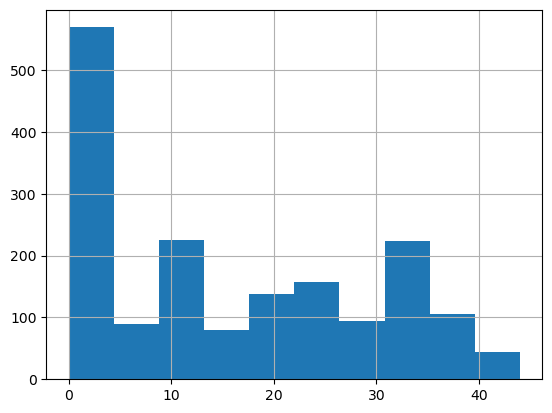

In [140]:
# Find NN
features.metadata.DolphinID.hist()

<Axes: >

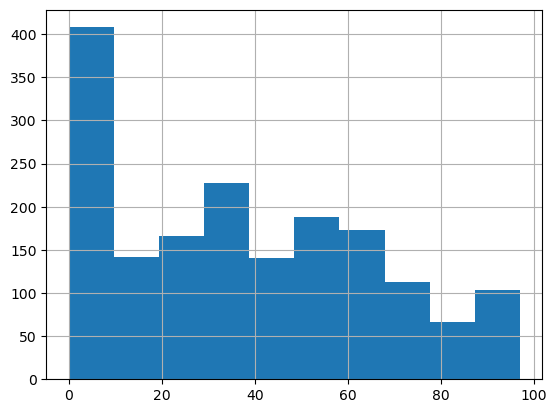

In [141]:
features.metadata.FinID.hist()

## Find NN

In [199]:
features.metadata["automatic_group"] = ""

In [197]:
dolphin_count_in_img = features.metadata.orig_img[features.metadata.DolphinID !=0 ].value_counts() 
# exclude unclassied dolphin
NN_group_dict = dict()
creat_empty_folder(root_dir + "/NN")
for i in range(len(dolphin_count_in_img)):
    img_name = dolphin_count_in_img.index[i]
    dolphin_count = dolphin_count_in_img[img_name]
    if dolphin_count > 1:
        dolphins_in_same_img = features.metadata.query("orig_img=='%s'"%(img_name))
        NNGroupName = ""
        dolphin_id_list = dolphins_in_same_img.DolphinID.sort_values().values
        for dolphin_id in dolphin_id_list:
            NNGroupName = NNGroupName + "_DphID%03d"%dolphin_id
        src = root_dir + "/" + img_name
        dest_dir = root_dir + "/NN/" + NNGroupName[1:] 
        dest = dest_dir + "/" + img_name
        if not Path(dest_dir).exists():
            os.mkdir(dest_dir)
        if not os.path.exists(dest):
            os.symlink(src, dest)

Deleted: /media/filming/2025-白海豚/20240824_JM_01/NN


In [223]:
dolphin_count_in_img = features.metadata.orig_img[features.metadata.DolphinID !=0 ].value_counts() 
# exclude unclassied dolphin
NN_group_dict = dict()
for i in range(len(dolphin_count_in_img)):
    img_name = dolphin_count_in_img.index[i]
    dolphin_count = dolphin_count_in_img[img_name]
    if dolphin_count > 1:
        dolphins_in_same_img = features.metadata.query("orig_img=='%s'"%(img_name))
        NNGroupName = ""
        dolphin_id_list = dolphins_in_same_img.DolphinID.sort_values().values
        for dolphin_id in dolphin_id_list:
            NNGroupName = NNGroupName + "_DphID%03d"%dolphin_id
        NNGroupName = NNGroupName[1:]
        if not NNGroupName in NN_group_dict.keys():
            NN_group_dict[NNGroupName] = []
        NN_group_dict[NNGroupName].append(img_name)

In [251]:
NN_group_dict

{'DphID001_DphID006': ['1379_20240824JM01ZRA11379.JPG',
  '1378_20240824JM01ZRA11378.JPG'],
 'DphID002_DphID011': ['1476_20240824JM01ZRA11476.JPG',
  '1475_20240824JM01ZRA11475.JPG',
  '1474_20240824JM01ZRA11474.JPG'],
 'DphID019_DphID019': ['1808_20240824JM01ZRA11808.JPG'],
 'DphID004_DphID012': ['1487_20240824JM01ZRA11487.JPG',
  '1549_20240824JM01ZRA11549.JPG',
  '1544_20240824JM01ZRA11544.JPG',
  '1545_20240824JM01ZRA11545.JPG',
  '1546_20240824JM01ZRA11546.JPG',
  '1547_20240824JM01ZRA11547.JPG',
  '1548_20240824JM01ZRA11548.JPG',
  '1488_20240824JM01ZRA11488.JPG',
  '1489_20240824JM01ZRA11489.JPG',
  '1551_20240824JM01ZRA11551.JPG',
  '1550_20240824JM01ZRA11550.JPG'],
 'DphID004_DphID005': ['1287_20240824JM01ZRA11287.JPG',
  '1330_20240824JM01ZRA11330.JPG',
  '1329_20240824JM01ZRA11329.JPG',
  '1331_20240824JM01ZRA11331.JPG',
  '1327_20240824JM01ZRA11327.JPG',
  '1326_20240824JM01ZRA11326.JPG',
  '1325_20240824JM01ZRA11325.JPG',
  '1324_20240824JM01ZRA11324.JPG',
  '1323_20240824

In [256]:
group_idx = 1
for key in NN_group_dict.keys():
    group_name = "NN%02d"%group_idx
    for img in NN_group_dict[key]:
        features.metadata.loc[ features.metadata['orig_img']==img, "automatic_group"] = group_name
    group_idx = group_idx + 1

In [257]:
features.metadata.automatic_group.value_counts()

automatic_group
        1576
NN05      32
NN06      28
NN04      22
NN11      22
NN12      12
NN14       6
NN02       6
NN07       4
NN01       4
NN10       4
NN03       2
NN13       2
NN15       2
NN08       2
NN09       2
Name: count, dtype: int64

In [258]:
features.metadata.to_csv(root_dir + "FILTERED_metainfo_with_FinID_with_dolphinID_with_groupID.csv")

In [259]:
features.metadata["confirmed_group"] = ""

In [272]:
# find the dophin id from folder structure
MCP_dir = root_dir + "/MCP"
MCP_list = os.listdir(MCP_dir)
MCP_list.sort()
MCP_idx = 1
for MCP in MCP_list:
    img_list  = glob.glob(os.path.join(MCP_dir + "/" + MCP, '*.JPG'))
    MCP_name = "MCP%02d"%(MCP_idx)
    for  img in img_list:
        img_name = os.path.basename(img)
        features.metadata.loc[ features.metadata['orig_img']==img_name, "confirmed_group"] = MCP_name
    MCP_idx = MCP_idx + 1
features.metadata.to_csv(root_dir + "/FILTERED_metainfo_with_FinID_with_dolphinID_with_automatic_confirm_group.csv")
features.save(root_dir + "FILTERED_deepfeatures_with_label_with_dolphinID_with_automatic_confirm_group")

In [275]:
# find the dophin id from folder structure
NN_dir = root_dir + "/NN"
NN_list = os.listdir(NN_dir)
NN_list.sort()
NN_idx = 1
for NN in NN_list:
    img_list  = glob.glob(os.path.join(NN_dir + "/" + NN, '*.JPG'))
    NN_name = "NN%02d"%(NN_idx)
    for  img in img_list:
        img_name = os.path.basename(img)
        features.metadata.loc[ features.metadata['orig_img']==img_name, "confirmed_group"] = NN_name
    NN_idx = NN_idx + 1
features.metadata.to_csv(root_dir + "/FILTERED_metainfo_with_FinID_with_dolphinID_with_automatic_confirm_group.csv")
features.save(root_dir + "FILTERED_deepfeatures_with_label_with_dolphinID_with_automatic_confirm_group")

In [273]:
features.metadata.confirmed_group.value_counts()

confirmed_group
         1616
MCP03      32
MCP01      28
MCP04      22
MCP05      22
MCP02       6
Name: count, dtype: int64

In [283]:
features.metadata.orig_img.unique()

array(['1214_20240824JM01ZRA11214.JPG', '1215_20240824JM01ZRA11215.JPG',
       '1216_20240824JM01ZRA11216.JPG', ...,
       '0045_20240824JM01ZRA10045.JPG', '0046_20240824JM01ZRA10046.JPG',
       '0047_20240824JM01ZRA10047.JPG'], shape=(1633,), dtype=object)

In [291]:
# move low quality images
features.metadata.loc[features.metadata['DolphinID'] !=0, 'orig_img'].unique()

array(['1214_20240824JM01ZRA11214.JPG', '1215_20240824JM01ZRA11215.JPG',
       '1216_20240824JM01ZRA11216.JPG', ...,
       '0069_20240824JM01ZRA10069.JPG', '0071_20240824JM01ZRA10071.JPG',
       '0072_20240824JM01ZRA10072.JPG'], shape=(1477,), dtype=object)

In [288]:
unclassied_img  = [i for i in features.metadata.orig_img.unique() if i not in features.metadata.loc[features.metadata['DolphinID'] !=0, 'orig_img'].unique()]

In [293]:
for img in unclassied_img:
    src = root_dir + "/" + img
    dest_dir = root_dir + "/Quality below 60"
    dest = dest_dir + "/" + img
    if not Path(dest_dir).exists():
        os.mkdir(dest_dir)
    if not os.path.exists(dest):
        os.symlink(src, dest)

Convert softlink to regular file
```bash
for f in $(find MCP/ -type l);do cp --remove-destination $(readlink $f) $f;done;
```